# 06 — Robustness Evaluation

This notebook contains the **final evaluation** of the project. It compares the two previously trained approaches:

* the TF-IDF + Logistic Regression baseline from [`04_baseline_model.ipynb`](04_baseline_model.ipynb)
* the three fine-tuned `gbert-base` models from [`05_transformer_model.ipynb`](05_transformer_model.ipynb)

All models are evaluated on two types of test data:

1. The clean and previously untouched test set in **`data/processed/test.csv`**, which serves as the reference.
2. All perturbed test sets in **`data/perturbed/`**. These cover five perturbation types at three different intensities: typos, casing changes, umlaut variants, word elongation, and informal slang substitutions.

In addition to comparing the overall performance, the notebook also investigates possible reasons for performance degradation. For `gbert-base`, it examines whether perturbed texts are split into more WordPiece subword tokens. For the baseline model, it checks whether perturbed words are no longer covered by the TF-IDF vocabulary.

The notebook runs entirely locally. Unlike notebook 05, no model training is required, so the evaluation only performs inference and can run somewhat efficiently on my MacBook M2 using MPS.


## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from src import config, evaluate, model, transformer_models, robustness

EVAL_BATCH_SIZE = 32
device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f"device: {device}")

device: mps


In [2]:
test_df = pd.read_csv(config.PROCESSED_DIR / "test.csv")
perturbed_df = pd.read_csv(config.PERTURBED_DIR / "test_perturbed_all.csv")

test_df.shape, perturbed_df.shape

((3532, 4), (52980, 7))

## 1. Load trained models

The baseline is a single fitted vectorizer + classifier. The transformer
has three independently fine-tuned checkpoints (seeds 42, 123, 67), each
loaded from its own saved directory under
`results/transformer/gbert-base/`.

In [3]:
baseline_vectorizer = joblib.load(config.MODELS_DIR / "baseline_tfidf_vectorizer.joblib")
baseline_clf = joblib.load(config.MODELS_DIR / "baseline_logreg.joblib")

In [4]:
transformer_checkpoints = {}
for seed in config.FINE_TUNE_SEEDS:
    checkpoint_dir = config.RESULTS_DIR / "transformer" / config.TRANSFORMER_MODEL_NAME / f"seed_{seed}"
    tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
    tf_model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir)
    tf_model.to(device)
    tf_model.eval()
    transformer_checkpoints[seed] = (tf_model, tokenizer)

list(transformer_checkpoints.keys())

[42, 123, 67]

## 2. Clean test-set performance 

In [5]:
baseline_clean_f1 = model.evaluate_baseline_on_df(baseline_vectorizer, baseline_clf, test_df, text_col="text")

transformer_clean_f1 = {
    seed: transformer_models.evaluate_transformer_on_df(
        tf_model, tokenizer, test_df, text_col="text",
        max_length=config.TRANSFORMER_MAX_LENGTH, batch_size=EVAL_BATCH_SIZE, device=device,
    )
    for seed, (tf_model, tokenizer) in transformer_checkpoints.items()
}
transformer_clean_mean = float(np.mean(list(transformer_clean_f1.values())))
transformer_clean_std = float(np.std(list(transformer_clean_f1.values()), ddof=1))

print(f"baseline clean macro-F1:     {baseline_clean_f1:.4f}")
print(f"gbert-base clean macro-F1:   {transformer_clean_mean:.4f} ± {transformer_clean_std:.4f}  {transformer_clean_f1}")

baseline clean macro-F1:     0.6445
gbert-base clean macro-F1:   0.7731 ± 0.0039  {42: 0.7760942019633001, 123: 0.7744694118689288, 67: 0.7686403100775194}


## 3. Robustness under perturbation

Both models are evaluated on every combination of perturbation type and intensity. Predictions are made using the `text_perturbed` column and compared with the true labels.

The three transformer seeds are evaluated separately. Their results are then combined and reported as mean ± standard deviation


In [6]:
baseline_rows = []
transformer_rows = []

for (ptype, intensity), group in perturbed_df.groupby(["perturbation_type", "intensity"]):
    baseline_f1 = model.evaluate_baseline_on_df(baseline_vectorizer, baseline_clf, group, text_col="text_perturbed")
    baseline_rows.append({"perturbation_type": ptype, "intensity": intensity, "macro_f1": baseline_f1})

    for seed, (tf_model, tokenizer) in transformer_checkpoints.items():
        f1 = transformer_models.evaluate_transformer_on_df(
            tf_model, tokenizer, group, text_col="text_perturbed",
            max_length=config.TRANSFORMER_MAX_LENGTH, batch_size=EVAL_BATCH_SIZE, device=device,
        )
        transformer_rows.append({"perturbation_type": ptype, "intensity": intensity, "seed": seed, "macro_f1": f1})

    print(f"done: {ptype} @ {intensity:.0%}")

baseline_results_df = pd.DataFrame(baseline_rows)
transformer_results_df = pd.DataFrame(transformer_rows)

done: casing @ 5%
done: casing @ 10%
done: casing @ 20%
done: elongation @ 5%
done: elongation @ 10%
done: elongation @ 20%
done: slang @ 5%
done: slang @ 10%
done: slang @ 20%
done: typo @ 5%
done: typo @ 10%
done: typo @ 20%
done: umlaut @ 5%
done: umlaut @ 10%
done: umlaut @ 20%


In [7]:
transformer_summary_df = (
    transformer_results_df.groupby(["perturbation_type", "intensity"])["macro_f1"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "macro_f1_mean", "std": "macro_f1_std"})
)
transformer_summary_df

,perturbation_type,intensity,macro_f1_mean,macro_f1_std
0,casing,0.05,0.743021,0.000958
1,casing,0.10,0.711743,0.001995
2,casing,0.20,0.652938,0.011193
3,elongation,0.05,0.771134,0.002721
4,elongation,0.10,0.772777,0.001421
5,elongation,0.20,0.763387,0.003198
6,slang,0.05,0.775639,0.004952
7,slang,0.10,0.776711,0.005782
8,slang,0.20,0.776303,0.006152
9,typo,0.05,0.734784,0.001802


### Summary tables

Perturbation type (rows) × intensity (columns), for a compact side-by-side
comparison.

In [8]:
baseline_pivot = baseline_results_df.pivot(index="perturbation_type", columns="intensity", values="macro_f1")
print("baseline macro-F1")
baseline_pivot

baseline macro-F1


intensity,0.05,0.10,0.20
perturbation_type,,,
casing,0.644921,0.645163,0.644014
elongation,0.634552,0.638844,0.625644
slang,0.641793,0.639411,0.637140
typo,0.617728,0.599259,0.538098
umlaut,0.642979,0.642016,0.639032


In [9]:
transformer_pivot = transformer_summary_df.pivot(index="perturbation_type", columns="intensity", values="macro_f1_mean")
print("gbert-base macro-F1 (mean across seeds)")
transformer_pivot

gbert-base macro-F1 (mean across seeds)


intensity,0.05,0.10,0.20
perturbation_type,,,
casing,0.743021,0.711743,0.652938
elongation,0.771134,0.772777,0.763387
slang,0.775639,0.776711,0.776303
typo,0.734784,0.698364,0.615663
umlaut,0.764672,0.762669,0.765494


### Degradation curves

Each panel shows the results for one perturbation type. Macro-F1 is plotted against perturbation intensity, with the clean test-set result included as the shared reference point at intensity 0.

For the transformer model, the line shows the mean performance across the three seeds. The shaded area represents ±1 standard deviation.


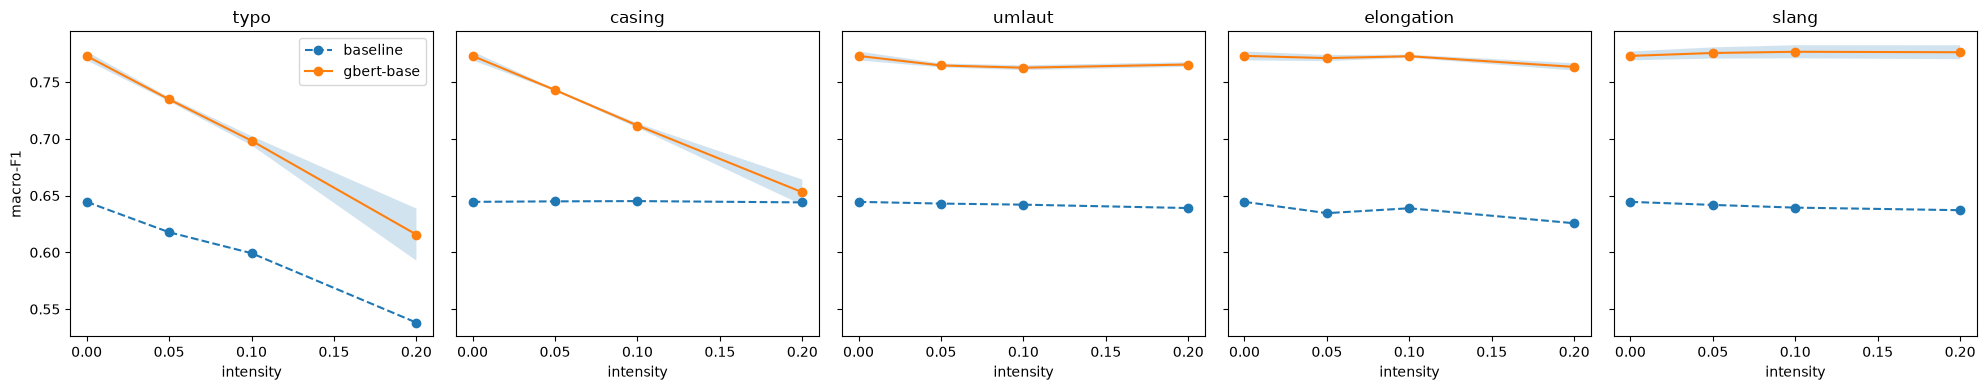

In [10]:
clean_baseline_rows = pd.DataFrame([
    {"perturbation_type": ptype, "intensity": 0.0, "macro_f1": baseline_clean_f1}
    for ptype in config.PERTURBATION_TYPES
])
baseline_plot_df = pd.concat([clean_baseline_rows, baseline_results_df], ignore_index=True)
baseline_plot_df = baseline_plot_df.sort_values(["perturbation_type", "intensity"])

clean_transformer_rows = pd.DataFrame([
    {"perturbation_type": ptype, "intensity": 0.0, "macro_f1_mean": transformer_clean_mean, "macro_f1_std": transformer_clean_std}
    for ptype in config.PERTURBATION_TYPES
])
transformer_plot_df = pd.concat([clean_transformer_rows, transformer_summary_df], ignore_index=True)
transformer_plot_df = transformer_plot_df.sort_values(["perturbation_type", "intensity"])

fig, axes = plt.subplots(1, len(config.PERTURBATION_TYPES), figsize=(20, 4), sharey=True)
for ax, ptype in zip(axes, config.PERTURBATION_TYPES):
    b = baseline_plot_df[baseline_plot_df["perturbation_type"] == ptype]
    t = transformer_plot_df[transformer_plot_df["perturbation_type"] == ptype]

    ax.plot(b["intensity"], b["macro_f1"], "o--", label="baseline")
    ax.plot(t["intensity"], t["macro_f1_mean"], "o-", label="gbert-base")
    ax.fill_between(
        t["intensity"], t["macro_f1_mean"] - t["macro_f1_std"], t["macro_f1_mean"] + t["macro_f1_std"], alpha=0.2
    )
    ax.set_title(ptype)
    ax.set_xlabel("intensity")

axes[0].set_ylabel("macro-F1")
axes[0].legend()
plt.tight_layout()
plt.show()

## 4. Tokenization fragmentation vs. degradation (`gbert-base`)

The fragmentation ratio compares the number of WordPiece tokens in the perturbed text with the number in the original clean text. Special tokens are excluded from this calculation.

A ratio above 1 means that the perturbation caused the text to be split into more subword tokens. This can indicate that the altered words are less familiar to the tokenizer and may help explain a drop in model performance.

Fine-tuning does not change the tokenizer or its vocabulary, so all three transformer checkpoints produce identical tokenization results. One checkpoint is loaded again in this section only to keep the analysis self-contained and easy to follow.


In [11]:
fragmentation_tokenizer = AutoTokenizer.from_pretrained(config.TRANSFORMER_CHECKPOINT)

fragmentation_rows = []
for (ptype, intensity), group in perturbed_df.groupby(["perturbation_type", "intensity"]):
    ratios = robustness.token_fragmentation_ratio(fragmentation_tokenizer, group["text"], group["text_perturbed"])
    fragmentation_rows.append({
        "perturbation_type": ptype,
        "intensity": intensity,
        "mean_fragmentation_ratio": float(np.mean(ratios)),
    })

fragmentation_df = pd.DataFrame(fragmentation_rows)
fragmentation_df

,perturbation_type,intensity,mean_fragmentation_ratio
0,casing,0.05,1.216343
1,casing,0.10,1.379449
2,casing,0.20,1.627547
3,elongation,0.05,1.093730
4,elongation,0.10,1.138423
5,elongation,0.20,1.242578
6,slang,0.05,1.008750
7,slang,0.10,1.008559
8,slang,0.20,1.008791
9,typo,0.05,1.190677


Pearson r (fragmentation ratio vs. macro-F1 drop): 0.923


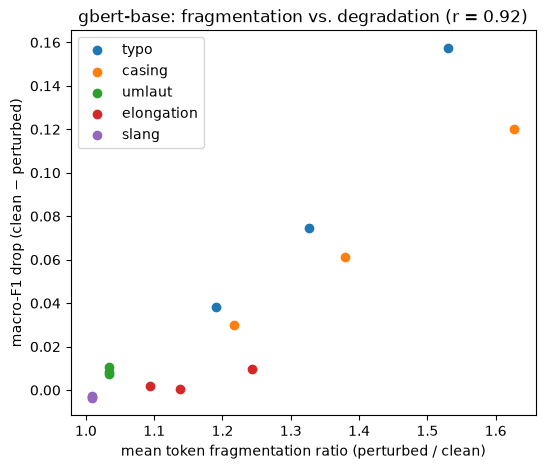

In [12]:
transformer_degradation_df = fragmentation_df.merge(transformer_summary_df, on=["perturbation_type", "intensity"])
transformer_degradation_df["macro_f1_drop"] = transformer_clean_mean - transformer_degradation_df["macro_f1_mean"]

fragmentation_corr = transformer_degradation_df["mean_fragmentation_ratio"].corr(transformer_degradation_df["macro_f1_drop"])
print(f"Pearson r (fragmentation ratio vs. macro-F1 drop): {fragmentation_corr:.3f}")

plt.figure(figsize=(6, 5))
for ptype in config.PERTURBATION_TYPES:
    subset = transformer_degradation_df[transformer_degradation_df["perturbation_type"] == ptype]
    plt.scatter(subset["mean_fragmentation_ratio"], subset["macro_f1_drop"], label=ptype)
plt.xlabel("mean token fragmentation ratio (perturbed / clean)")
plt.ylabel("macro-F1 drop (clean − perturbed)")
plt.title(f"gbert-base: fragmentation vs. degradation (r = {fragmentation_corr:.2f})")
plt.legend()
plt.show()

## 5. Vocabulary misses vs. degradation (baseline)

Unlike `gbert-base`, the baseline has no subword tokenization. A perturbed word either matches an n-gram that the TF-IDF vectorizer learned during training or it is not represented by the model at all.

The out-of-vocabulary (OOV) rate measures the proportion of unigram tokens in a text that are missing from the fitted TF-IDF vocabulary. It therefore provides a baseline-specific equivalent to the transformer’s fragmentation ratio and helps explain why certain perturbations lead to a larger drop in performance.


In [13]:
oov_rows = []
for (ptype, intensity), group in perturbed_df.groupby(["perturbation_type", "intensity"]):
    rates = robustness.oov_rate(baseline_vectorizer, group["text_perturbed"])
    oov_rows.append({
        "perturbation_type": ptype,
        "intensity": intensity,
        "mean_oov_rate": float(np.mean(rates)),
    })

oov_df = pd.DataFrame(oov_rows)
oov_df

,perturbation_type,intensity,mean_oov_rate
0,casing,0.05,0.175542
1,casing,0.10,0.175843
2,casing,0.20,0.176035
3,elongation,0.05,0.241107
4,elongation,0.10,0.271615
5,elongation,0.20,0.342281
6,slang,0.05,0.188166
7,slang,0.10,0.188587
8,slang,0.20,0.188462
9,typo,0.05,0.339469


Pearson r (OOV rate vs. macro-F1 drop): 0.957


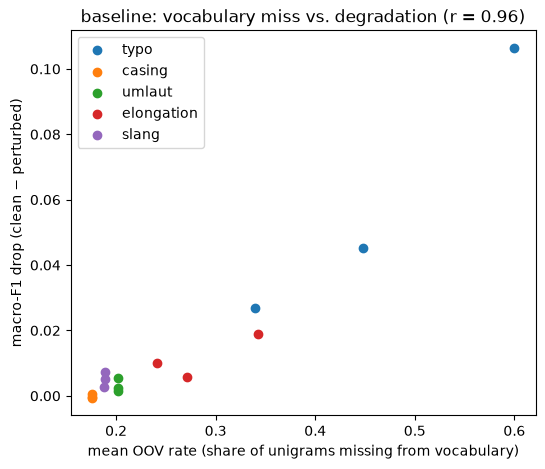

In [14]:
baseline_degradation_df = oov_df.merge(baseline_results_df, on=["perturbation_type", "intensity"])
baseline_degradation_df["macro_f1_drop"] = baseline_clean_f1 - baseline_degradation_df["macro_f1"]

oov_corr = baseline_degradation_df["mean_oov_rate"].corr(baseline_degradation_df["macro_f1_drop"])
print(f"Pearson r (OOV rate vs. macro-F1 drop): {oov_corr:.3f}")

plt.figure(figsize=(6, 5))
for ptype in config.PERTURBATION_TYPES:
    subset = baseline_degradation_df[baseline_degradation_df["perturbation_type"] == ptype]
    plt.scatter(subset["mean_oov_rate"], subset["macro_f1_drop"], label=ptype)
plt.xlabel("mean OOV rate (share of unigrams missing from vocabulary)")
plt.ylabel("macro-F1 drop (clean − perturbed)")
plt.title(f"baseline: vocabulary miss vs. degradation (r = {oov_corr:.2f})")
plt.legend()
plt.show()

## 6. Save results

All score tables, plus the fragmentation/OOV tables used for the
degradation analysis, are saved to `results/robustness/` for the final
report.

In [15]:
robustness_dir = config.RESULTS_DIR / "robustness"
robustness_dir.mkdir(parents=True, exist_ok=True)

baseline_results_df.to_csv(robustness_dir / "baseline_scores.csv", index=False)
transformer_results_df.to_csv(robustness_dir / "transformer_scores_per_seed.csv", index=False)
transformer_summary_df.to_csv(robustness_dir / "transformer_scores_summary.csv", index=False)
fragmentation_df.to_csv(robustness_dir / "fragmentation.csv", index=False)
oov_df.to_csv(robustness_dir / "oov_rates.csv", index=False)

with open(robustness_dir / "clean_reference.txt", "w") as f:
    f.write(f"baseline clean macro-F1: {baseline_clean_f1:.4f}\n")
    f.write(f"gbert-base clean macro-F1: {transformer_clean_mean:.4f} ± {transformer_clean_std:.4f}\n")
    f.write(f"gbert-base per-seed clean macro-F1: {transformer_clean_f1}\n")

print("saved baseline_scores.csv, transformer_scores_per_seed.csv, transformer_scores_summary.csv, "
      "fragmentation.csv, oov_rates.csv, clean_reference.txt")

saved baseline_scores.csv, transformer_scores_per_seed.csv, transformer_scores_summary.csv, fragmentation.csv, oov_rates.csv, clean_reference.txt
